In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
import skimage as ski
import SimpleITK as sitk
from PIL import Image
import cv2

In [17]:
input_images = []
sample_ids = [
	"S1585-2_a",
  	"S1585-2_b",
]
for sample_id in sample_ids:
	input_image = np.array(Image.open(f"../data/{sample_id}/image.png").convert("RGB"))[:,:,1]
	mask_image = np.array(Image.open(f"../data/{sample_id}/mask.png").convert("L"))
	label_image = np.array(Image.open(f"../data/{sample_id}/label.png").convert("L"))

	mask_uint8 = mask_image.astype(np.uint8) * 255

	offset_px = 100
	kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, offset_px * 6))
	anchor = (0, offset_px*6 - 1)
	dilated = cv2.dilate(mask_uint8, kernel, anchor=anchor, iterations=1)

	dermis_available_mask =  dilated - mask_uint8
	dermis_mask = cv2.bitwise_and(dermis_available_mask , cv2.dilate(mask_uint8, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (offset_px,offset_px)), iterations=1))
	roi_mask = cv2.bitwise_or(dermis_mask.astype(np.uint8), mask_uint8.astype(np.uint8))
	
	input_images.append((input_image, label_image,roi_mask))
		

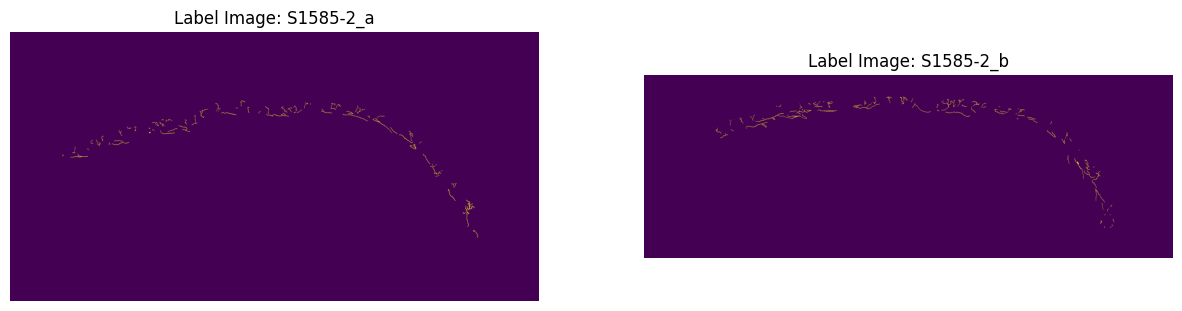

In [19]:
label_img = [label for _, label, _ in input_images]

_, ax = plt.subplots(1, len(sample_ids), figsize=(15, 5))
for i, img in enumerate(label_img):
	ax[i].imshow(img)
	ax[i].set_title(f"Label Image: {sample_ids[i]}")
	ax[i].axis('off')
plt.show()


Sample ID: S1585-2_a
Nerve fiber pixels: 30053
Skeleton pixels: 8185
Width distribution statistics:
  Min width: 2.00 pixels
  Max width: 10.00 pixels
  Mean width: 3.69 pixels
  Median width: 4.00 pixels
  Std dev: 0.94 pixels

Sample ID: S1585-2_b
Nerve fiber pixels: 31663
Skeleton pixels: 9270
Width distribution statistics:
  Min width: 2.00 pixels
  Max width: 12.65 pixels
  Mean width: 3.49 pixels
  Median width: 4.00 pixels
  Std dev: 0.98 pixels


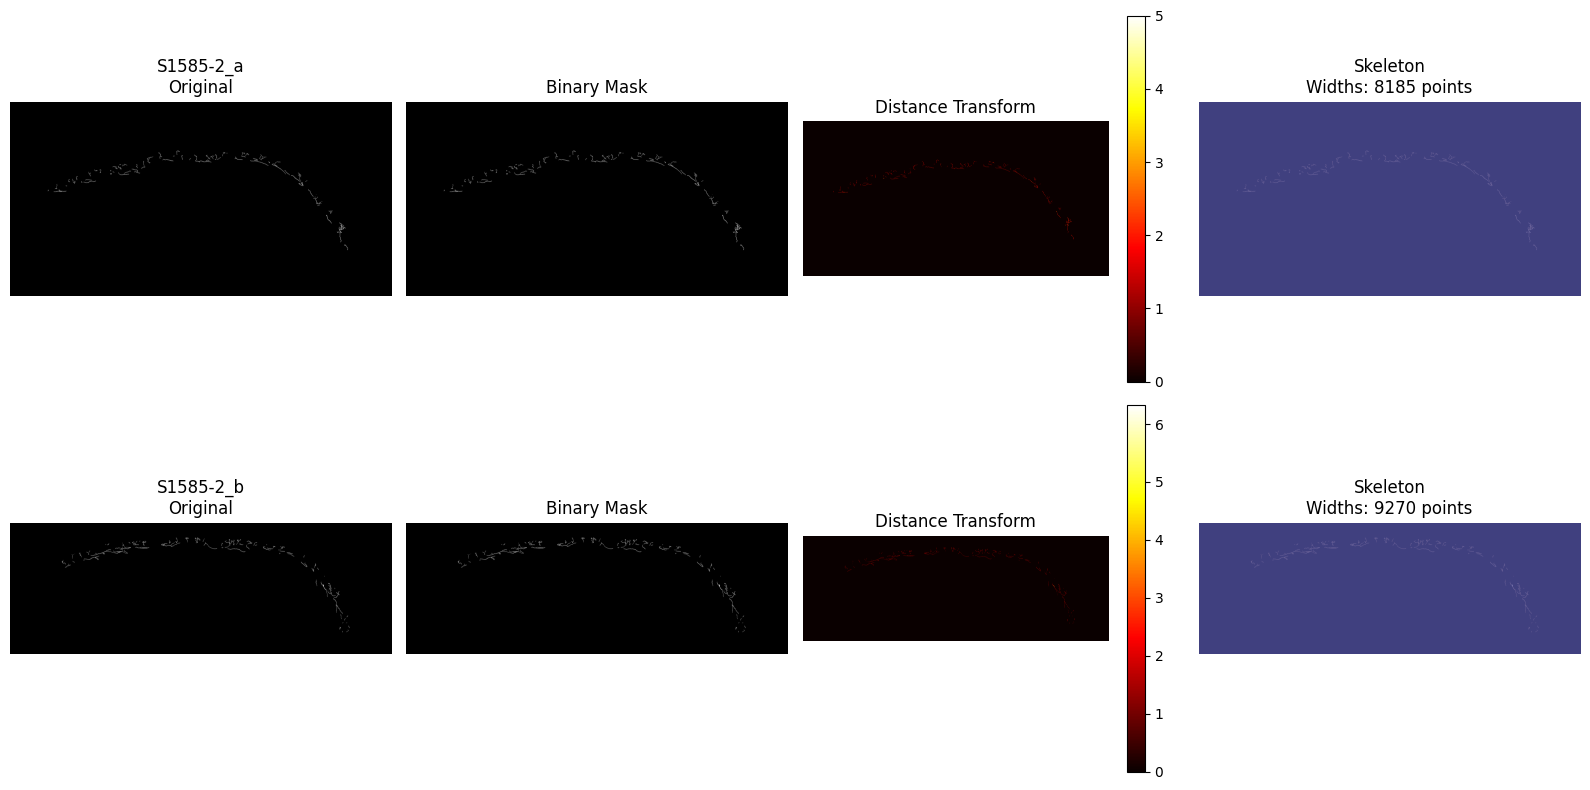

In [20]:
# Neural Fiber Width Distribution Topology Analysis
from scipy.ndimage import distance_transform_edt
from skimage.morphology import medial_axis

# Store all width data
all_widths = []
skeleton_data = []

fig, axes = plt.subplots(len(sample_ids), 4, figsize=(16, 4*len(sample_ids)))
if len(sample_ids) == 1:
    axes = axes.reshape(1, -1)

for idx, (sample_id, label_image) in enumerate(zip(sample_ids, label_img)):
    # Convert to binary image (0 or 1)
    img_array = np.array(label_image)
    
    # If RGB, convert to grayscale
    if len(img_array.shape) == 3:
        img_gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_array
    
    # Binarization: nerve fibers as foreground
    _, binary = cv2.threshold(img_gray, 127, 1, cv2.THRESH_BINARY)
    
    # Calculate distance transform
    dist_transform = distance_transform_edt(binary)
    
    # Get skeleton (medial axis)
    skeleton, distance = medial_axis(binary, return_distance=True)
    
    # Sample width values from skeleton (distance transform value * 2 = diameter)
    widths = distance[skeleton] * 2  # *2 because distance is from boundary to point
    widths = widths[widths > 0]  # Remove zeros
    
    all_widths.append(widths)
    skeleton_data.append({
        'sample_id': sample_id,
        'binary': binary,
        'dist_transform': dist_transform,
        'skeleton': skeleton,
        'widths': widths
    })
    
    # Display original image
    axes[idx, 0].imshow(img_array, cmap='gray')
    axes[idx, 0].set_title(f'{sample_id}\nOriginal')
    axes[idx, 0].axis('off')
    
    # Display binary image
    axes[idx, 1].imshow(binary, cmap='gray')
    axes[idx, 1].set_title('Binary Mask')
    axes[idx, 1].axis('off')
    
    # Display distance transform
    im = axes[idx, 2].imshow(dist_transform, cmap='hot')
    axes[idx, 2].set_title('Distance Transform')
    axes[idx, 2].axis('off')
    plt.colorbar(im, ax=axes[idx, 2])
    
    # Display skeleton
    axes[idx, 3].imshow(binary, cmap='gray', alpha=0.5)
    axes[idx, 3].imshow(skeleton, cmap='jet', alpha=0.5)
    axes[idx, 3].set_title(f'Skeleton\nWidths: {len(widths)} points')
    axes[idx, 3].axis('off')
    
    print(f"\n{'='*50}")
    print(f"Sample ID: {sample_id}")
    print(f"{'='*50}")
    print(f"Nerve fiber pixels: {np.sum(binary)}")
    print(f"Skeleton pixels: {np.sum(skeleton)}")
    print(f"Width distribution statistics:")
    print(f"  Min width: {np.min(widths):.2f} pixels")
    print(f"  Max width: {np.max(widths):.2f} pixels")
    print(f"  Mean width: {np.mean(widths):.2f} pixels")
    print(f"  Median width: {np.median(widths):.2f} pixels")
    print(f"  Std dev: {np.std(widths):.2f} pixels")

plt.tight_layout()
plt.show()

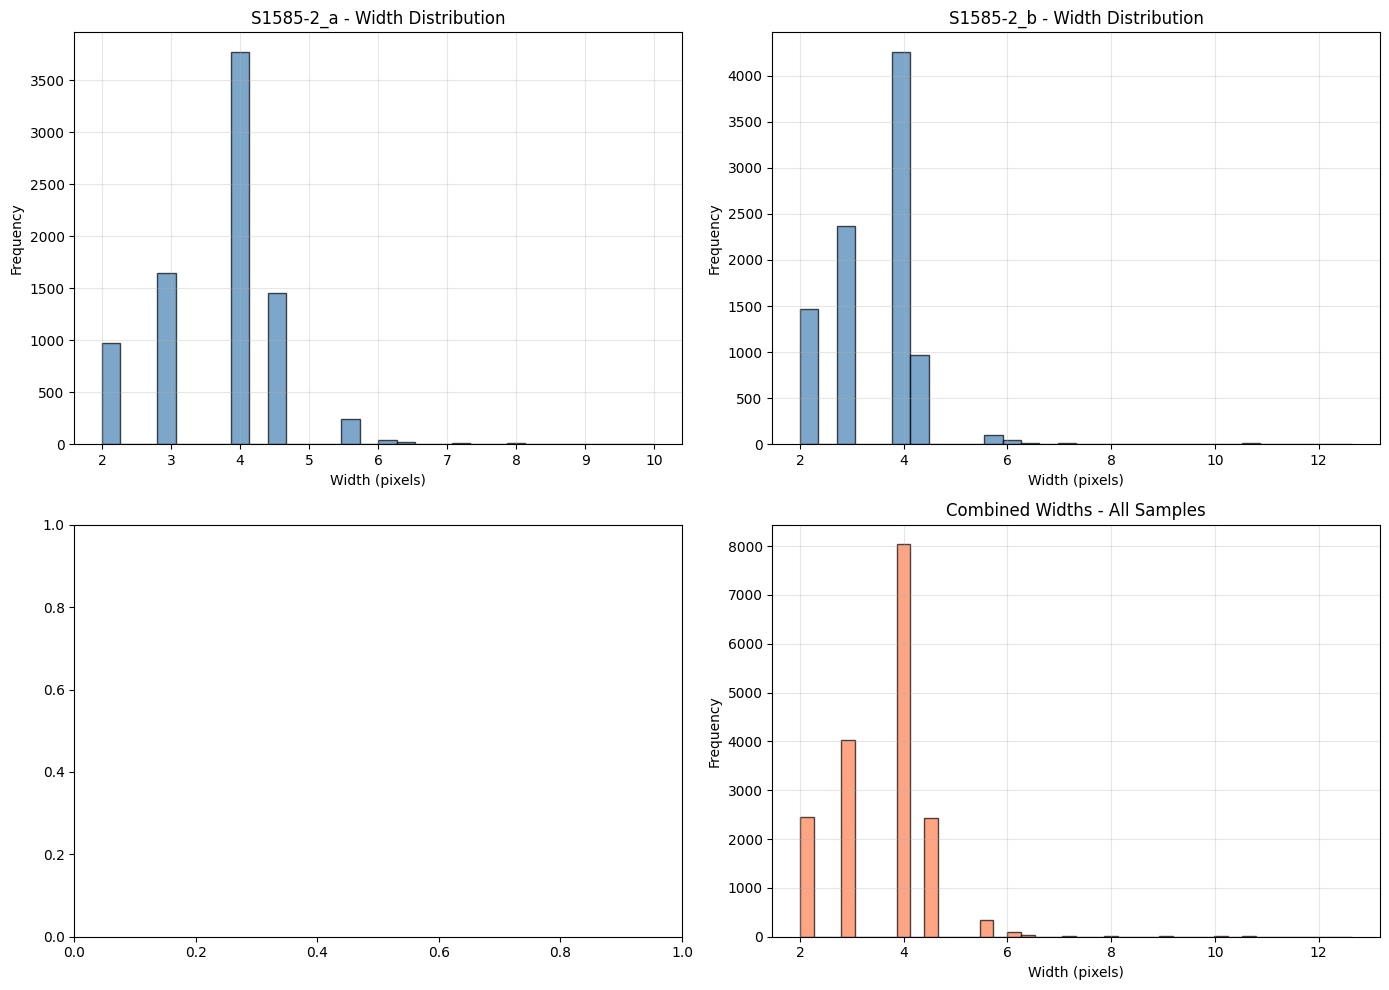


Overall Nerve Fiber Width Statistics Summary
Total samples: 17455
Min width: 2.00 pixels
Max width: 12.65 pixels
Mean width: 3.58 pixels
Median width: 4.00 pixels
Std dev: 0.97 pixels
25th percentile: 2.83 pixels
75th percentile: 4.00 pixels

Width Comparison by Sample

S1585-2_a:
  Sample count: 8185
  Mean: 3.69 ± 0.94 pixels
  Range: [2.00, 10.00]

S1585-2_b:
  Sample count: 9270
  Mean: 3.49 ± 0.98 pixels
  Range: [2.00, 12.65]


In [21]:
# Width Distribution Histogram
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Individual histogram for each sample
for idx, skeleton_info in enumerate(skeleton_data):
    if idx < 3:
        ax = axes[idx // 2, idx % 2]
        ax.hist(skeleton_info['widths'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        ax.set_xlabel('Width (pixels)')
        ax.set_ylabel('Frequency')
        ax.set_title(f"{skeleton_info['sample_id']} - Width Distribution")
        ax.grid(True, alpha=0.3)

# 2. Combined histogram of all samples (bottom right)
combined_widths = np.concatenate(all_widths)
axes[1, 1].hist(combined_widths, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Width (pixels)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Combined Widths - All Samples')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*60)
print("Overall Nerve Fiber Width Statistics Summary")
print("="*60)
print(f"Total samples: {len(combined_widths)}")
print(f"Min width: {np.min(combined_widths):.2f} pixels")
print(f"Max width: {np.max(combined_widths):.2f} pixels")
print(f"Mean width: {np.mean(combined_widths):.2f} pixels")
print(f"Median width: {np.median(combined_widths):.2f} pixels")
print(f"Std dev: {np.std(combined_widths):.2f} pixels")
print(f"25th percentile: {np.percentile(combined_widths, 25):.2f} pixels")
print(f"75th percentile: {np.percentile(combined_widths, 75):.2f} pixels")

# Comparison of each sample
print("\n" + "="*60)
print("Width Comparison by Sample")
print("="*60)
for skeleton_info in skeleton_data:
    widths = skeleton_info['widths']
    print(f"\n{skeleton_info['sample_id']}:")
    print(f"  Sample count: {len(widths)}")
    print(f"  Mean: {np.mean(widths):.2f} ± {np.std(widths):.2f} pixels")
    print(f"  Range: [{np.min(widths):.2f}, {np.max(widths):.2f}]")


Sample ID: S1585-2_a
Foreground (Nerve Fibers):
  Mean: 138.10
  Std Dev: 76.42
  Sample Count: 30053

Background:
  Mean: 79.81
  Std Dev: 67.21
  Sample Count: 89482

Fisher Score: 0.3281
  (Higher values indicate better foreground-background separation)

Sample ID: S1585-2_b
Foreground (Nerve Fibers):
  Mean: 149.63
  Std Dev: 75.37
  Sample Count: 31663

Background:
  Mean: 95.75
  Std Dev: 71.42
  Sample Count: 99312

Fisher Score: 0.2692
  (Higher values indicate better foreground-background separation)


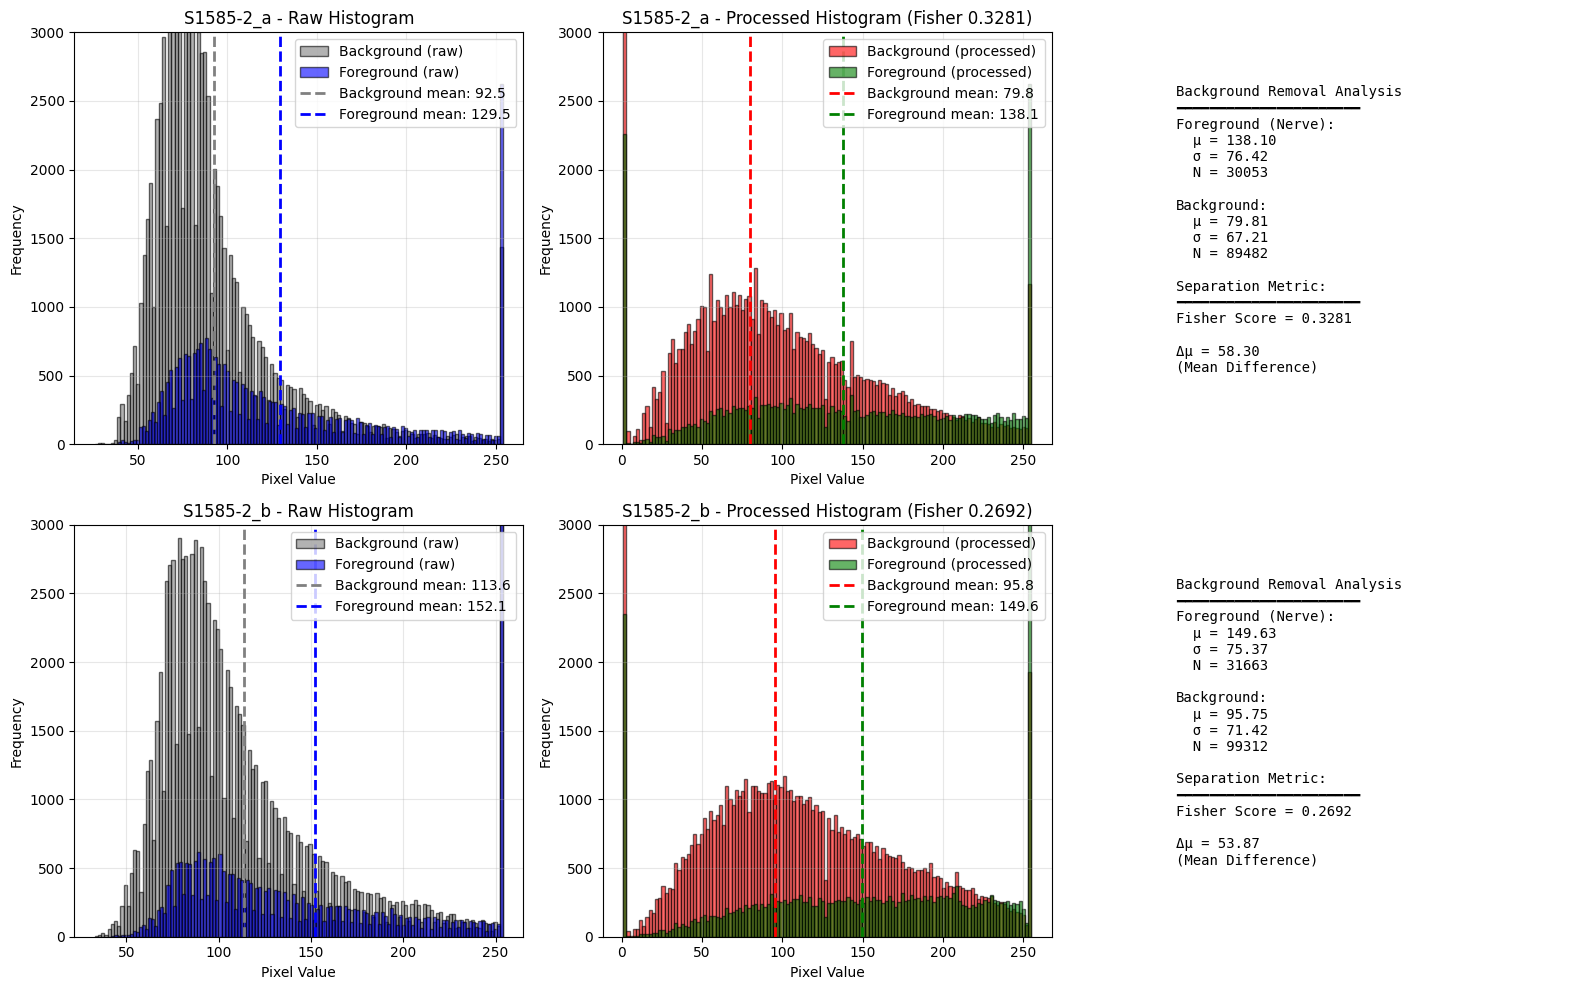


Fisher Score Comparison Across All Samples
S1585-2_a: Fisher Score = 0.3281
S1585-2_b: Fisher Score = 0.2692


In [ ]:
# Background Removal and Statistical Analysis Based on GT Mask (Fisher Score + Histogram)

def compute_fisher_score(foreground, background):
    """Compute Fisher Score"""
    mean_fg = np.mean(foreground)
    mean_bg = np.mean(background)
    var_fg = np.var(foreground)
    var_bg = np.var(background)
    
    denominator = var_fg + var_bg
    if denominator < 1e-10:
        return 0
    
    fisher_score = (mean_fg - mean_bg) ** 2 / denominator
    return fisher_score

# Collect analysis results
analysis_results = []

fig, axes = plt.subplots(len(sample_ids), 3, figsize=(16, 5*len(sample_ids)))
if len(sample_ids) == 1:
    axes = axes.reshape(1, -1)

for idx, (sample_id, (orig_img, label_image, _)) in enumerate(zip(sample_ids, input_images)):
    print(f"\n{'='*70}")
    print(f"Sample ID: {sample_id}")
    print(f"{'='*70}")
    

    roi_mask = cv2.morphologyEx(label_image, cv2.MORPH_DILATE, kernel=cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11)), iterations=1).astype(np.uint8) 
    # Convert label to binary mask (foreground=1, background=0)
    label_array = np.array(label_image)
    if len(label_array.shape) == 3:
        label_array = cv2.cvtColor(label_array, cv2.COLOR_RGB2GRAY)
    
    # Binarize mask
    _, mask = cv2.threshold(label_array, 127, 1, cv2.THRESH_BINARY)
    
    preprocessed = np.clip(orig_img, 0, 255).astype(np.uint8)
    
    # Calculate fine background (minimum of two radii)
    bg_small = ski.restoration.rolling_ball(preprocessed, radius=30)
    bg_tiny = ski.restoration.rolling_ball(preprocessed, radius=2)
    bg = np.minimum(bg_small, bg_tiny)
    

    bg_safe = np.maximum(bg, 1)  # Avoid division by zero
    fg_img = (preprocessed.astype(np.float32) / (bg_safe.astype(np.float32))).astype(np.float32)
    
    baseline = np.median(fg_img)
    lower_half_pixels = fg_img[fg_img < baseline]
	# 這裡計算的是 "半邊" 的標準差，足以代表背景雜訊水平
    noise_std = np.std(lower_half_pixels)

	# 3. 設定動態門檻 (3-Sigma Rule)
	# 統計學上，平均值 + 3倍標準差 可以涵蓋 99.7% 的雜訊
	# 也就是說，只要大於這個值，幾乎肯定是訊號，不是雜訊
    noise_gate = 2.5 * noise_std


    diff = fg_img - (baseline +  noise_gate)
    softness = 0.5  # 控制过渡的平滑程度
    soft_diff = diff * (1 / (1 + np.exp(-diff / softness)))
    diff = np.maximum(soft_diff, 0)
    

	# 2.2 穩健歸一化 (Robust Normalization) -> 關鍵！
	# 因為 Gamma 需要輸入是 0~1，我們用 99% 分位數來避免極值干擾
    v_max = np.percentile(diff[diff > 0], 99) if np.max(diff) > 0 else 1.0
    norm = diff / v_max
    norm = np.clip(norm, 0, 1) # 確保在 0~1 之間
	
	# 2.3 執行 Gamma
	# gamma > 1: 壓抑背景雜訊 (讓神經更乾淨)
	# gamma < 1: 提亮微弱神經 (讓神經更連續)
    enhanced = np.power(norm, 0.4) 
    
    fg_img = (enhanced * 254 + 1).astype(np.uint8)
    
    
    # ===== GT Mask Statistical Analysis =====
    # Separate foreground and background pixels (within ROI)
    foreground_pixels = fg_img[(mask == 1) & (roi_mask > 0)]
    background_pixels = fg_img[(mask == 0) & (roi_mask > 0)]
    
    # Compute Fisher Score
    fisher_score = compute_fisher_score(foreground_pixels, background_pixels)
    
    # Statistical information
    fg_mean = np.mean(foreground_pixels) if foreground_pixels.size else 0
    fg_std = np.std(foreground_pixels) if foreground_pixels.size else 0
    bg_mean = np.mean(background_pixels) if background_pixels.size else 0
    bg_std = np.std(background_pixels) if background_pixels.size else 0
    
    # Store results
    analysis_results.append({
        'sample_id': sample_id,
        'fisher_score': fisher_score,
        'fg_mean': fg_mean,
        'fg_std': fg_std,
        'bg_mean': bg_mean,
        'bg_std': bg_std,
        'fg_pixels': foreground_pixels,
        'bg_pixels': background_pixels,
        'fg_img': fg_img
    })
    
    # Print statistical information
    print(f"Foreground (Nerve Fibers):")
    print(f"  Mean: {fg_mean:.2f}")
    print(f"  Std Dev: {fg_std:.2f}")
    print(f"  Sample Count: {len(foreground_pixels)}")
    print(f"\nBackground:")
    print(f"  Mean: {bg_mean:.2f}")
    print(f"  Std Dev: {bg_std:.2f}")
    print(f"  Sample Count: {len(background_pixels)}")
    print(f"\nFisher Score: {fisher_score:.4f}")
    print(f"  (Higher values indicate better foreground-background separation)")
    
    # ===== Visualization =====
    # 1. Histogram before processing (raw image within ROI) with mean lines
    raw_foreground = orig_img[(mask == 1) & (roi_mask > 0)]
    raw_background = orig_img[(mask == 0) & (roi_mask > 0)]
    raw_fg_mean = np.mean(raw_foreground) if raw_foreground.size else 0
    raw_bg_mean = np.mean(raw_background) if raw_background.size else 0
    ax_raw = axes[idx, 0]
    ax_raw.hist(raw_background, bins=128, alpha=0.6, label='Background (raw)', color='gray', edgecolor='black')
    ax_raw.hist(raw_foreground, bins=128, alpha=0.6, label='Foreground (raw)', color='blue', edgecolor='black')
    ax_raw.axvline(raw_bg_mean, color='gray', linestyle='--', linewidth=2, label=f'Background mean: {raw_bg_mean:.1f}')
    ax_raw.axvline(raw_fg_mean, color='blue', linestyle='--', linewidth=2, label=f'Foreground mean: {raw_fg_mean:.1f}')
    ax_raw.set_xlabel('Pixel Value')
    ax_raw.set_ylabel('Frequency')
    ax_raw.set_ylim(0, 3000)
    ax_raw.set_title(f'{sample_id} - Raw Histogram')
    ax_raw.legend()
    ax_raw.grid(True, alpha=0.3)
    
    # 2. Histogram - Foreground and background separation after processing with mean lines
    ax_hist = axes[idx, 1]
    ax_hist.hist(background_pixels, bins=128, alpha=0.6, label='Background (processed)', color='red', edgecolor='black')
    ax_hist.hist(foreground_pixels, bins=128, alpha=0.6, label='Foreground (processed)', color='green', edgecolor='black')
    ax_hist.axvline(bg_mean, color='red', linestyle='--', linewidth=2, label=f'Background mean: {bg_mean:.1f}')
    ax_hist.axvline(fg_mean, color='green', linestyle='--', linewidth=2, label=f'Foreground mean: {fg_mean:.1f}')
    ax_hist.set_xlabel('Pixel Value')
    ax_hist.set_ylabel('Frequency')
    ax_hist.set_ylim(0, 3000)
    ax_hist.set_title(f'{sample_id} - Processed Histogram (Fisher {fisher_score:.4f})')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)
    
    # 3. Histogram - Statistical information
    ax_text = axes[idx, 2]
    ax_text.axis('off')
    stats_text = f"""Background Removal Analysis
━━━━━━━━━━━━━━━━━━━━━━
Foreground (Nerve):
  μ = {fg_mean:.2f}
  σ = {fg_std:.2f}
  N = {len(foreground_pixels)}

Background:
  μ = {bg_mean:.2f}
  σ = {bg_std:.2f}
  N = {len(background_pixels)}

Separation Metric:
━━━━━━━━━━━━━━━━━━━━━━
Fisher Score = {fisher_score:.4f}

Δμ = {abs(fg_mean - bg_mean):.2f}
(Mean Difference)
"""
    ax_text.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
                verticalalignment='center', transform=ax_text.transAxes)

plt.tight_layout()
plt.show()

# Summary of all samples
print(f"\n{'='*70}")
print("Fisher Score Comparison Across All Samples")
print(f"{'='*70}")
for result in analysis_results:
    print(f"{result['sample_id']}: Fisher Score = {result['fisher_score']:.4f}")


In [ ]:
# Grid Search to Optimize Fisher Score

# Define parameter space
r_big_values = [i for i in range(10,21,5)]
r_small_values = [i for i in range(1,5)]
fg_enhance_options = [False, True]

# Store grid search results
grid_results = []

print("Starting Grid Search to Optimize Fisher Score...")
print(f"Total parameter combinations: {len(r_big_values) * len(r_small_values) * len(fg_enhance_options)}")
print("="*80)

# Perform grid search for each sample
for sample_idx, (sample_id, orig_img, label_image) in enumerate(zip(sample_ids, input_images, label_img)):
    print(f"\n【Sample {sample_idx+1}/{len(sample_ids)}: {sample_id}】")
    
    # Prepare mask
    label_array = np.array(label_image)
    if len(label_array.shape) == 3:
        label_array = cv2.cvtColor(label_array, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(label_array, 127, 1, cv2.THRESH_BINARY)
    if mask.shape != orig_img.shape:
        mask = cv2.resize(mask, (orig_img.shape[1], orig_img.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    best_fisher = -1
    best_params = None
    sample_results = []
    
    # Grid search loop
    for r_big in r_big_values:
        for r_small in r_small_values:
            for fg_enhance in fg_enhance_options:
                preprocessed = np.clip(orig_img, 0, 255).astype(np.uint8)
                
                # Fine background calculation
                bg_small = ski.restoration.rolling_ball(preprocessed, radius=r_big)
                bg_tiny = ski.restoration.rolling_ball(preprocessed, radius=r_small)
                bg = np.minimum(bg_small, bg_tiny)
                
                # Background subtraction
                fg_img = (preprocessed.astype(float) - bg).clip(0, 255).astype(np.uint8)
                
                # Foreground enhancement (optional)
                if fg_enhance:
                    bg_norm = cv2.normalize(bg.astype(float), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
                    fg_gain = 1 + 0.5 * bg_norm
                    fg_img = (fg_img.astype(float) * fg_gain).clip(0, 255).astype(np.uint8)
                
                # Compute Fisher Score
                foreground_pixels = fg_img[mask == 1]
                background_pixels = fg_img[mask == 0]
                fisher_score = compute_fisher_score(foreground_pixels, background_pixels)
                
                # Record results
                result_entry = {
                    'sample_id': sample_id,
                    'r_big': r_big,
                    'r_small': r_small,
                    'fg_enhance': fg_enhance,
                    'fisher_score': fisher_score,
                    'fg_img': fg_img,
                    'fg_mean': np.mean(foreground_pixels),
                    'bg_mean': np.mean(background_pixels),
                }
                sample_results.append(result_entry)
                grid_results.append(result_entry)
                
                # Update best parameters
                if fisher_score > best_fisher:
                    best_fisher = fisher_score
                    best_params = (r_big, r_small, fg_enhance)
    
    # Print best parameters for this sample
    r_big_best, r_small_best, fg_enhance_best = best_params
    print(f"  Best Fisher Score: {best_fisher:.4f}")
    print(f"  Best Parameters:")
    print(f"    - r_big (large radius): {r_big_best}")
    print(f"    - r_small (small radius): {r_small_best}")
    print(f"    - Foreground enhance: {'Yes' if fg_enhance_best else 'No'}")
    
    # Sort sample results and display top 5
    sample_results_sorted = sorted(sample_results, key=lambda x: x['fisher_score'], reverse=True)
    print(f"  Top 5 parameter combinations:")
    for rank, res in enumerate(sample_results_sorted[:5], 1):
        enhance_str = 'Yes' if res['fg_enhance'] else 'No'
        print(f"    {rank}. Fisher Score={res['fisher_score']:.4f} | r_big={res['r_big']}, r_small={res['r_small']}, Enhance={enhance_str}")

print("\n" + "="*80)
print("Grid Search Complete!")
print("="*80)


開始Grid Search最佳化Fisher Score...
參數組合總數: 24

【樣本 1/2: S1585-2_a】
  最佳Fisher Score: 1.0700
  最佳參數:
    - r_big (大範圍半徑): 20
    - r_small (小範圍半徑): 1
    - 前景增強: 否
  前5名參數組合:
    1. Fisher Score=1.0700 | r_big=20, r_small=1, 增強=無
    2. Fisher Score=1.0700 | r_big=20, r_small=2, 增強=無
    3. Fisher Score=1.0700 | r_big=20, r_small=3, 增強=無
    4. Fisher Score=1.0700 | r_big=20, r_small=4, 增強=無
    5. Fisher Score=1.0466 | r_big=15, r_small=1, 增強=無

【樣本 2/2: S1585-2_b】
  最佳Fisher Score: 1.3422
  最佳參數:
    - r_big (大範圍半徑): 20
    - r_small (小範圍半徑): 1
    - 前景增強: 否
  前5名參數組合:
    1. Fisher Score=1.3422 | r_big=20, r_small=1, 增強=無
    2. Fisher Score=1.3422 | r_big=20, r_small=2, 增強=無
    3. Fisher Score=1.3422 | r_big=20, r_small=3, 增強=無
    4. Fisher Score=1.3422 | r_big=20, r_small=4, 增強=無
    5. Fisher Score=1.3114 | r_big=20, r_small=1, 增強=有

Grid Search完成！


【全局最佳參數組合】
樣本: S1585-2_b
Fisher Score: 1.3422
參數: r_big=20, r_small=1, 前景增強=否


/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:54: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:54: UserWarning: Glyph 31684 (\N{CJK UNIFIED IDEOGRAPH-7BC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:54: UserWarning: Glyph 22285 (\N{CJK UNIFIED IDEOGRAPH-570D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:54: UserWarning: Glyph 21322 (\N{CJK UNIFIED IDEOGRAPH-534A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:54: UserWarning: Glyph 24465 (\N{CJK UNIFIED IDEOGRAPH-5F91}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sg

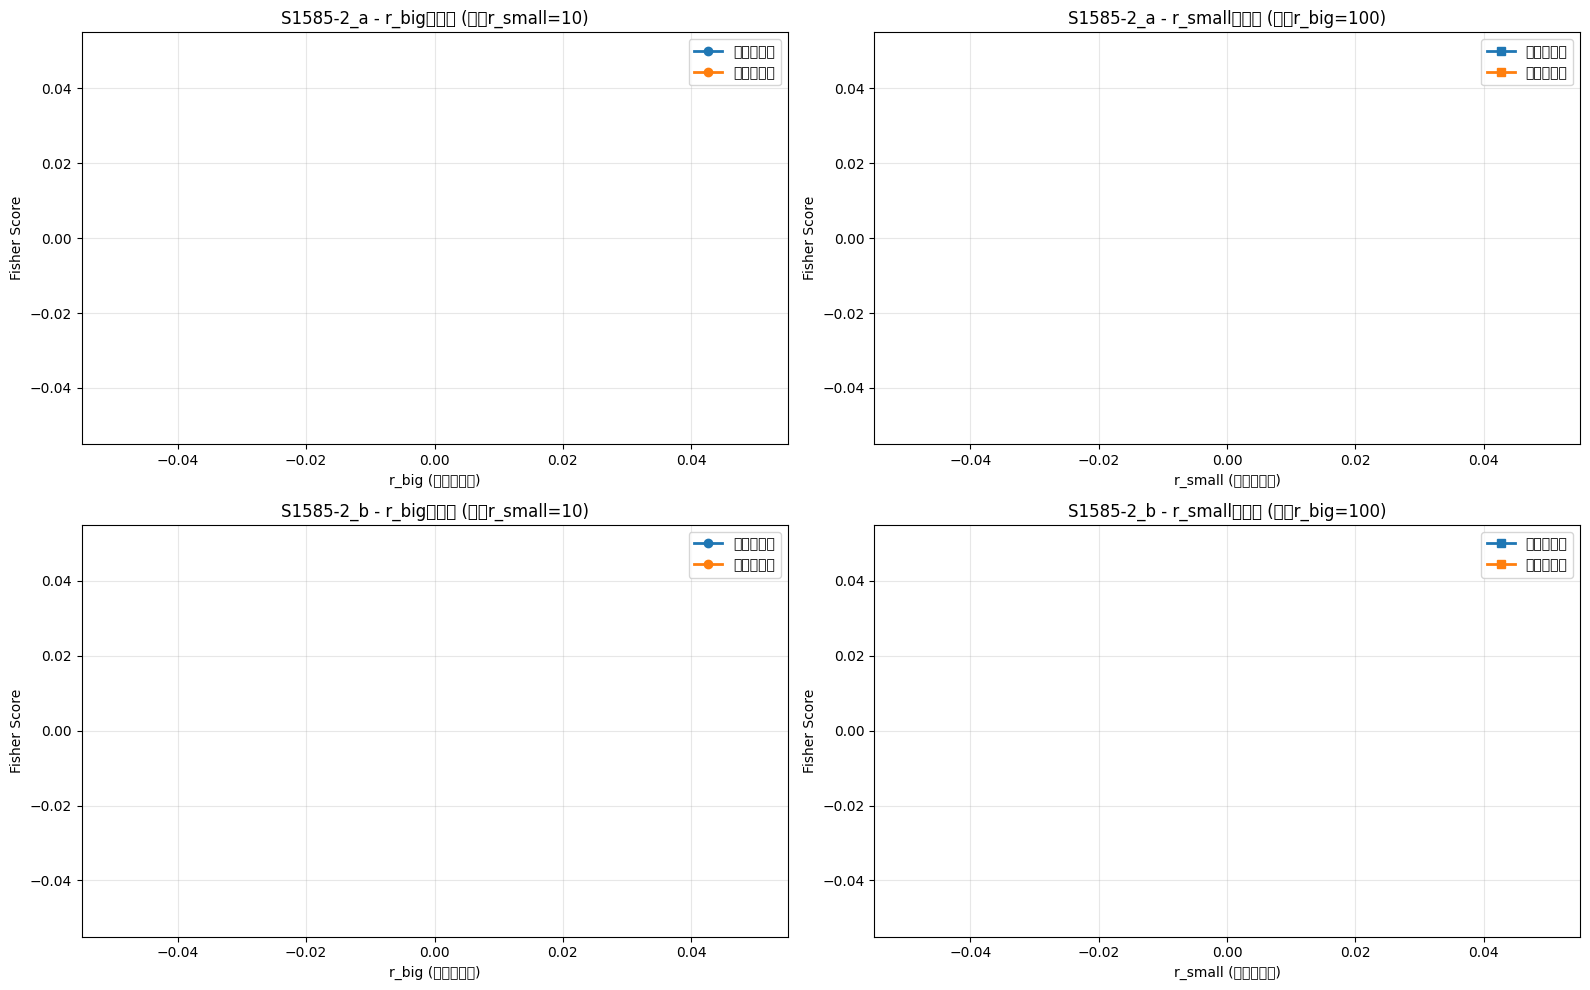


【前景增強效應分析】
S1585-2_a:
  無增強平均Fisher Score: 1.0477
  有增強平均Fisher Score: 1.0179
  改善幅度: -2.85%
S1585-2_b:
  無增強平均Fisher Score: 1.2979
  有增強平均Fisher Score: 1.2650
  改善幅度: -2.54%

【參數組合性能熱力圖】


/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 29105 (\N{CJK UNIFIED IDEOGRAPH-71B1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 28961 (\N{CJK UNIFIED IDEOGRAPH-7121}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8

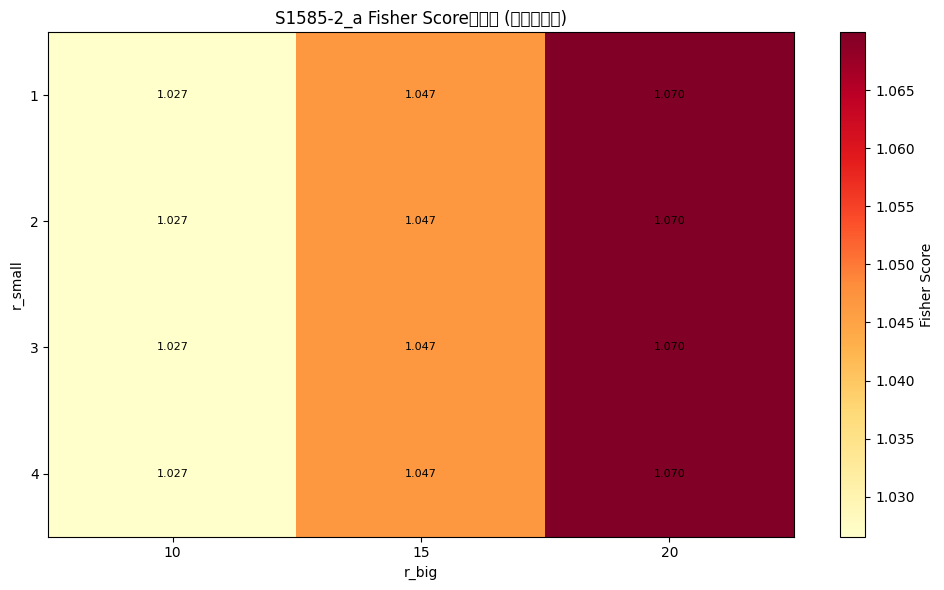

/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 29105 (\N{CJK UNIFIED IDEOGRAPH-71B1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8

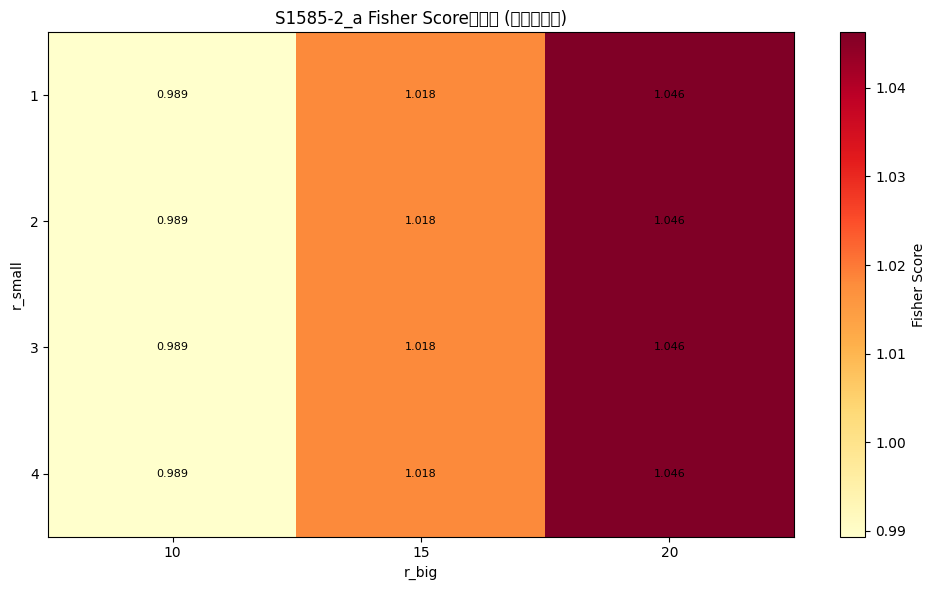

/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 29105 (\N{CJK UNIFIED IDEOGRAPH-71B1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 28961 (\N{CJK UNIFIED IDEOGRAPH-7121}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8

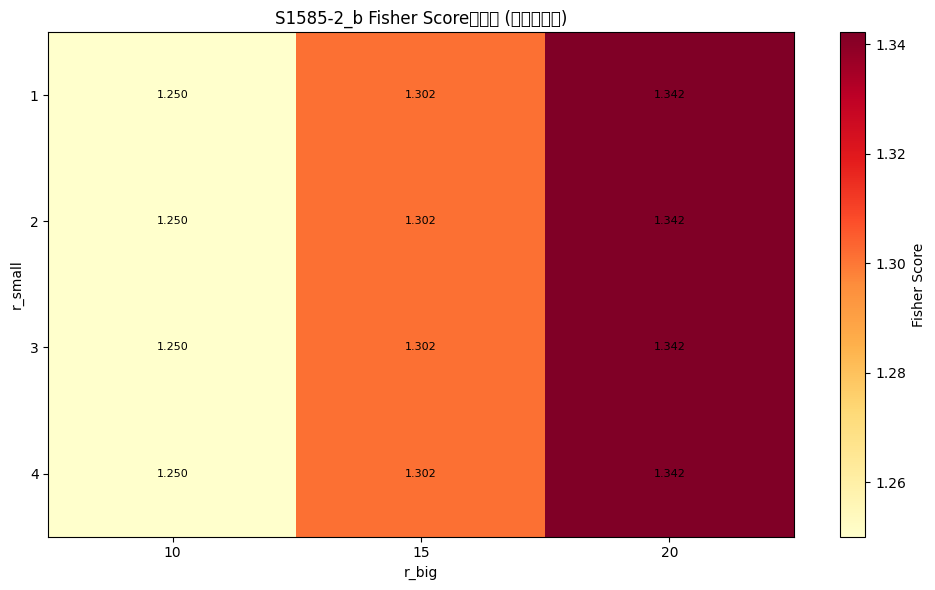

/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 29105 (\N{CJK UNIFIED IDEOGRAPH-71B1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_31093/1683154800.py:109: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8

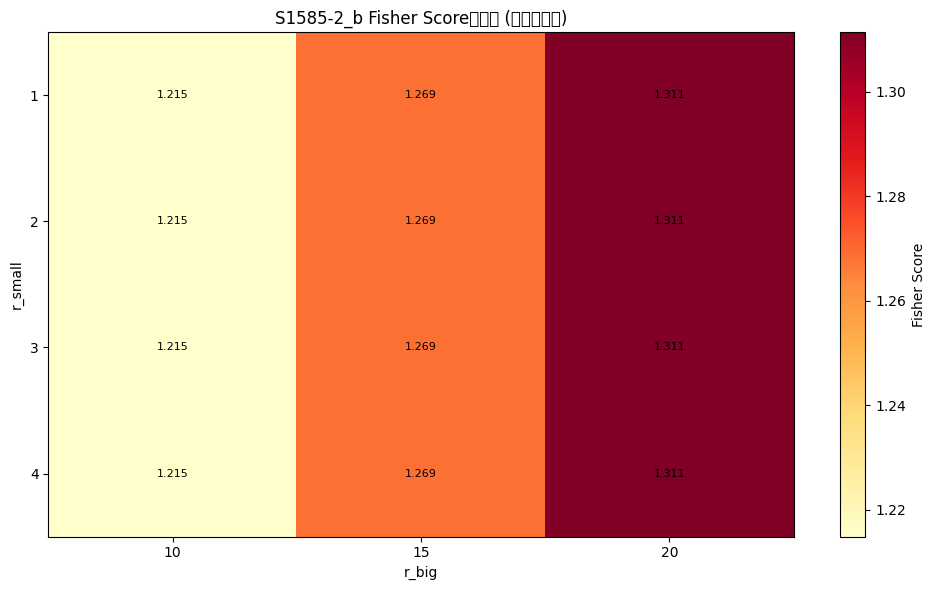


Grid Search視覺化完成！


In [ ]:
# Grid Search Results Visualization and Comparison

import pandas as pd

# Convert to DataFrame for analysis
df_results = pd.DataFrame(grid_results)

# 1. Global best parameters
print("【Global Best Parameter Combination】")
print("="*80)
global_best = df_results.loc[df_results['fisher_score'].idxmax()]
print(f"Sample: {global_best['sample_id']}")
print(f"Fisher Score: {global_best['fisher_score']:.4f}")
print(f"Parameters: r_big={global_best['r_big']}, r_small={global_best['r_small']}, FG Enhance={'Yes' if global_best['fg_enhance'] else 'No'}")

# 2. Parameter effect analysis for each sample
fig, axes = plt.subplots(len(sample_ids), 2, figsize=(16, 5*len(sample_ids)))
if len(sample_ids) == 1:
    axes = axes.reshape(1, -1)

for idx, sample_id in enumerate(sample_ids):
    df_sample = df_results[df_results['sample_id'] == sample_id]
    
    # Effect plot 1: r_big impact (fixed r_small=10)
    ax1 = axes[idx, 0]
    df_fixed = df_sample[df_sample['r_small'] == 10].sort_values('r_big')
    
    for fg_enhance in [False, True]:
        df_data = df_fixed[df_fixed['fg_enhance'] == fg_enhance]
        label = 'With FG Enhance' if fg_enhance else 'Without FG Enhance'
        ax1.plot(df_data['r_big'], df_data['fisher_score'], marker='o', label=label, linewidth=2)
    
    ax1.set_xlabel('r_big (Large Radius)')
    ax1.set_ylabel('Fisher Score')
    ax1.set_title(f'{sample_id} - r_big Impact (Fixed r_small=10)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Effect plot 2: r_small impact (fixed r_big=100)
    ax2 = axes[idx, 1]
    df_fixed2 = df_sample[df_sample['r_big'] == 100].sort_values('r_small')
    
    for fg_enhance in [False, True]:
        df_data = df_fixed2[df_fixed2['fg_enhance'] == fg_enhance]
        label = 'With FG Enhance' if fg_enhance else 'Without FG Enhance'
        ax2.plot(df_data['r_small'], df_data['fisher_score'], marker='s', label=label, linewidth=2)
    
    ax2.set_xlabel('r_small (Small Radius)')
    ax2.set_ylabel('Fisher Score')
    ax2.set_title(f'{sample_id} - r_small Impact (Fixed r_big=100)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Foreground enhancement effect
print("\n【Foreground Enhancement Effect Analysis】")
print("="*80)
for sample_id in sample_ids:
    df_sample = df_results[df_results['sample_id'] == sample_id]
    
    score_no_enhance = df_sample[df_sample['fg_enhance'] == False]['fisher_score'].mean()
    score_with_enhance = df_sample[df_sample['fg_enhance'] == True]['fisher_score'].mean()
    improvement = ((score_with_enhance - score_no_enhance) / score_no_enhance) * 100
    
    print(f"{sample_id}:")
    print(f"  Avg Fisher Score (No Enhance): {score_no_enhance:.4f}")
    print(f"  Avg Fisher Score (With Enhance): {score_with_enhance:.4f}")
    print(f"  Improvement: {improvement:+.2f}%")

# 4. Create heatmap - Fisher Score distribution across parameter combinations
print("\n【Parameter Combination Performance Heatmap】")
print("="*80)
for sample_id in sample_ids:
    df_sample = df_results[df_results['sample_id'] == sample_id]
    
    for fg_enhance in [False, True]:
        df_enhance = df_sample[df_sample['fg_enhance'] == fg_enhance]
        
        # Create pivot table for heatmap
        pivot_data = df_enhance.pivot_table(
            values='fisher_score',
            index='r_small',
            columns='r_big',
            aggfunc='mean'
        )
        
        fig, ax = plt.subplots(figsize=(10, 6))
        im = ax.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto')
        
        # Annotate values
        for i in range(len(pivot_data.index)):
            for j in range(len(pivot_data.columns)):
                text = ax.text(j, i, f'{pivot_data.values[i, j]:.3f}',
                             ha="center", va="center", color="black", fontsize=8)
        
        ax.set_xticks(range(len(pivot_data.columns)))
        ax.set_yticks(range(len(pivot_data.index)))
        ax.set_xticklabels(pivot_data.columns)
        ax.set_yticklabels(pivot_data.index)
        ax.set_xlabel('r_big')
        ax.set_ylabel('r_small')
        
        enhance_text = '(With FG Enhance)' if fg_enhance else '(Without FG Enhance)'
        ax.set_title(f'{sample_id} Fisher Score Heatmap {enhance_text}')
        
        plt.colorbar(im, ax=ax, label='Fisher Score')
        plt.tight_layout()
        plt.show()

print("\n" + "="*80)
print("Grid Search Visualization Complete!")
